# Customer Intelligence System
###Classification, Ensemble & Clustering
### Unsupervised Learning on Country Data

**Name:** Manish Alley | **Week 3** | Celebal Technologies DS Internship

**Objective:** Develop an end-to-end Customer Intelligence System using clustering (K-Means, DBSCAN) and PCA to segment countries based on socioeconomic indicators and generate actionable insights.

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights

## 1) Install required libraries

In [16]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## 2) Import libraries

In [17]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.edgecolor': '#cccccc',
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

PALETTE = ['#2E86AB', '#E84855', '#3BB273', '#F4A261', '#A23B72']

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

print('Libraries imported successfully!')

Libraries imported successfully!


## 3) Load the dataset

Upload the CSV file from Kaggle when prompted.

In [18]:
from google.colab import files

print('Upload Country-data.csv:')
uploaded = files.upload()

csv_name = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[csv_name]))

print(f'Loaded: {csv_name}')
print(f'Shape: {df.shape}')
df.head()

Upload Country-data.csv:


Saving Country-data.csv to Country-data (1).csv
Loaded: Country-data (1).csv
Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick inspection

In [19]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp

In [20]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [21]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]

before = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed: {before - len(df)}')

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']

print(f'Missing before: {df[numeric_cols].isna().sum().sum()}')
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print(f'Missing after:  {df[numeric_cols].isna().sum().sum()}')

print(f'Clean shape: {df.shape}')
df.isna().sum()

Duplicates removed: 0
Missing before: 0
Missing after:  0
Clean shape: (167, 10)


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


## 7) Exploratory Data Analysis

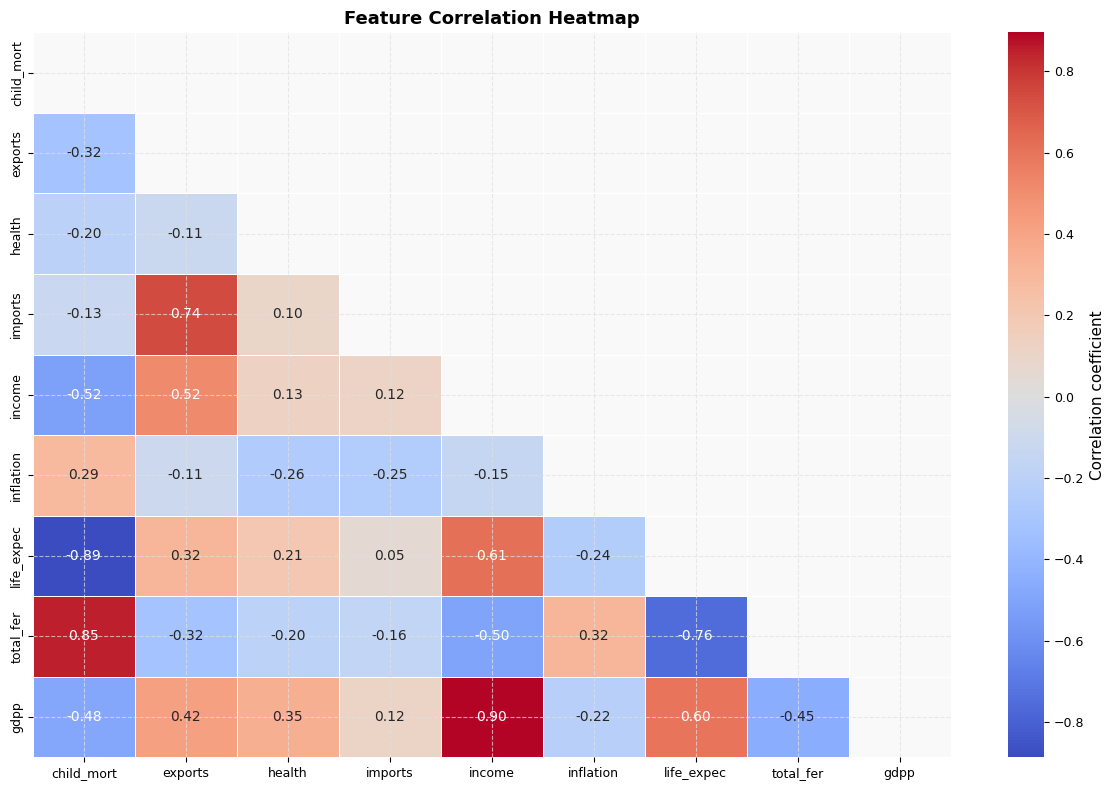

In [22]:
fig, ax = plt.subplots(figsize=(12, 8))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, linewidths=0.5,
            cbar_kws={'label': 'Correlation coefficient'},
            ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

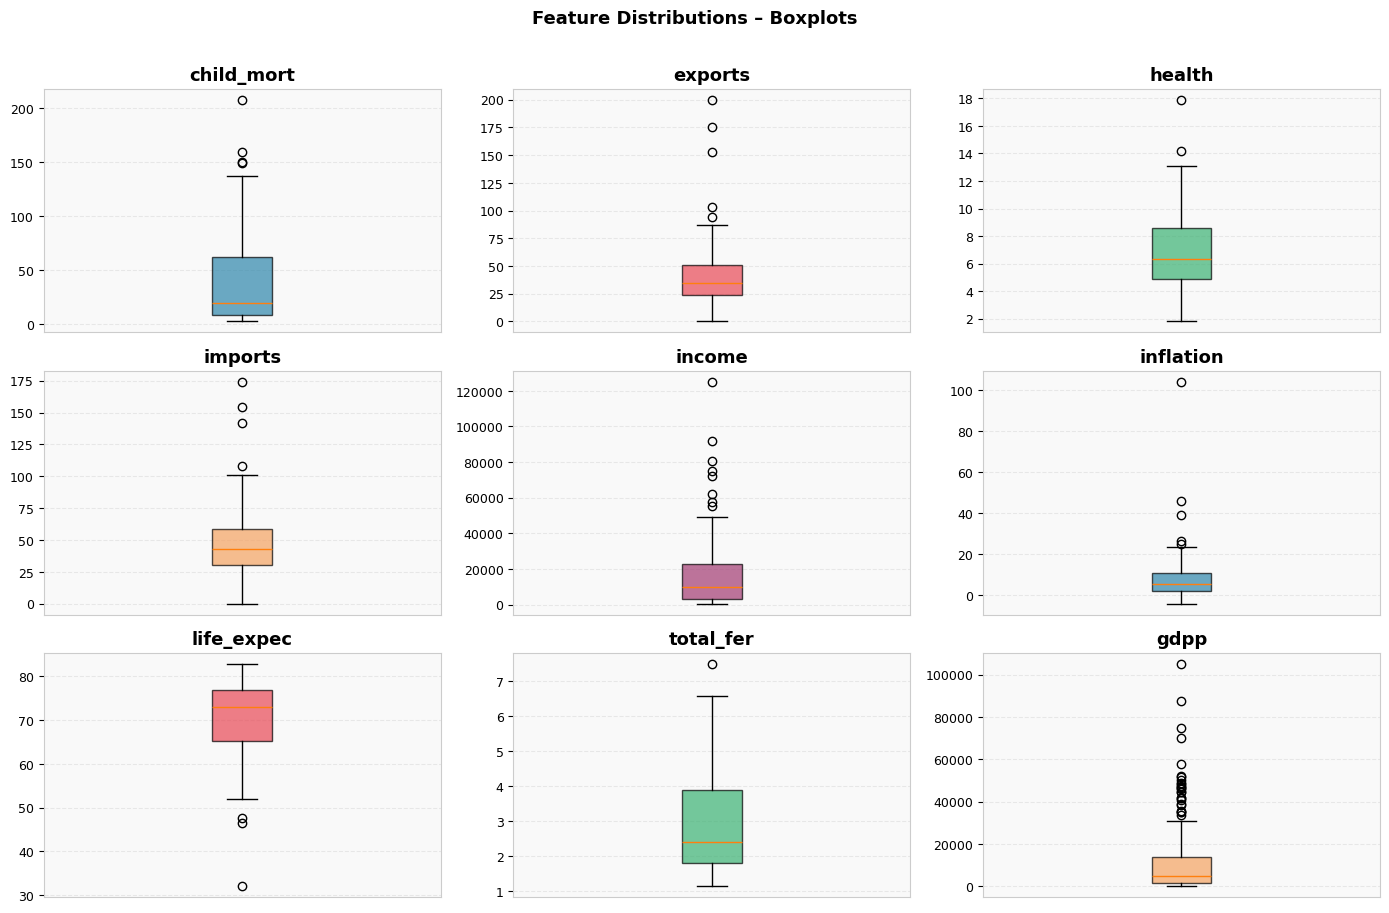

In [23]:
n = len(numeric_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(14, rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=PALETTE[i % len(PALETTE)], alpha=0.7))
    axes[i].set_title(col)
    axes[i].set_xticks([])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions – Boxplots', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 8) Feature scaling

Clustering works better when features are on the same scale. K-Means uses Euclidean distance so large-range features like income or gdpp would dominate without scaling.

In [24]:
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(f'Scaled shape: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean(axis=0).round(3)}')
print(f'Std  (should be ~1): {X_scaled.std(axis=0).round(3)}')

Scaled shape: (167, 9)
Mean (should be ~0): [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 9) K-Means: Elbow method

k=2  →  inertia: 1050.21
k=3  →  inertia: 831.42
k=4  →  inertia: 700.52
k=5  →  inertia: 620.16
k=6  →  inertia: 558.47
k=7  →  inertia: 495.81
k=8  →  inertia: 457.59
k=9  →  inertia: 427.80
k=10  →  inertia: 403.23


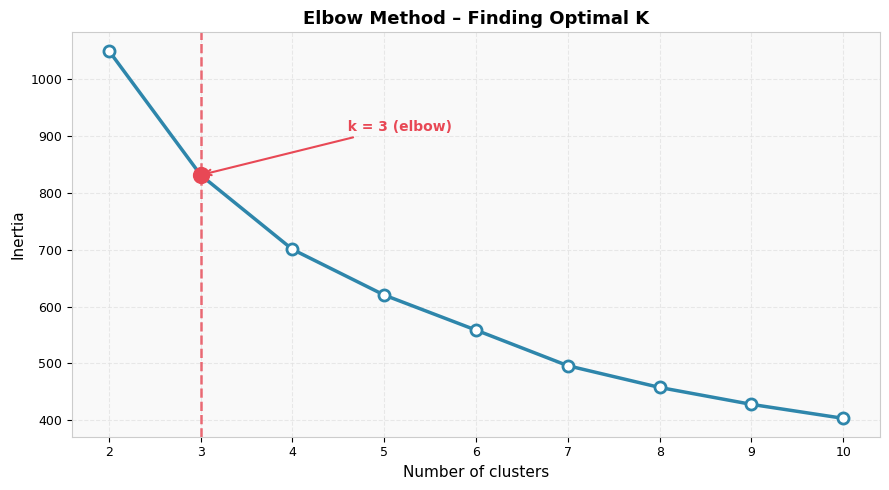

The inertia drops sharply up to k=3 then slows down — clear elbow point.


In [25]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)
    print(f'k={k}  →  inertia: {model.inertia_:.2f}')

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(list(k_values), inertias,
        color=PALETTE[0], linewidth=2.5,
        marker='o', markersize=8,
        markerfacecolor='white', markeredgewidth=2, markeredgecolor=PALETTE[0])

ax.axvline(x=3, color=PALETTE[1], linestyle='--', linewidth=1.8, alpha=0.8)
ax.scatter([3], [inertias[1]], color=PALETTE[1], s=130, zorder=5)
ax.annotate('  k = 3 (elbow)',
            xy=(3, inertias[1]),
            xytext=(4.5, inertias[1] + (inertias[0] - inertias[-1]) * 0.12),
            fontsize=10, color=PALETTE[1], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=PALETTE[1], lw=1.5))

ax.set_title('Elbow Method – Finding Optimal K')
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Inertia')
ax.set_xticks(list(k_values))
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print('The inertia drops sharply up to k=3 then slows down — clear elbow point.')

## 10) Train K-Means

In [26]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, df['kmeans_cluster']))
print('\nCountries per cluster:')
print(df['kmeans_cluster'].value_counts().sort_index())

df[['country', 'kmeans_cluster']].head() if 'country' in df.columns else df[['kmeans_cluster']].head()

Silhouette Score: 0.28329575683463126

Countries per cluster:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## 11) Try DBSCAN

In [27]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise = (df['dbscan_cluster'] == -1).sum()

print(f'DBSCAN clusters found: {n_clusters_db}')
print(f'Noise/outlier points:  {n_noise}')
print('\nLabel distribution:')
print(df['dbscan_cluster'].value_counts().sort_index())

if n_noise > 0 and 'country' in df.columns:
    print('\nOutlier countries:', df[df['dbscan_cluster'] == -1]['country'].tolist())

DBSCAN clusters found: 1
Noise/outlier points:  30

Label distribution:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

Outlier countries: ['Angola', 'Brunei', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Gabon', 'Haiti', 'Iraq', 'Ireland', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Luxembourg', 'Malta', 'Micronesia, Fed. Sts.', 'Mongolia', 'Nigeria', 'Norway', 'Qatar', 'Rwanda', 'Seychelles', 'Sierra Leone', 'Singapore', 'South Africa', 'Timor-Leste', 'Turkmenistan', 'United States', 'Venezuela']


## 12) PCA visualization

PC1: 45.95%  |  PC2: 17.18%  |  Total: 63.13%


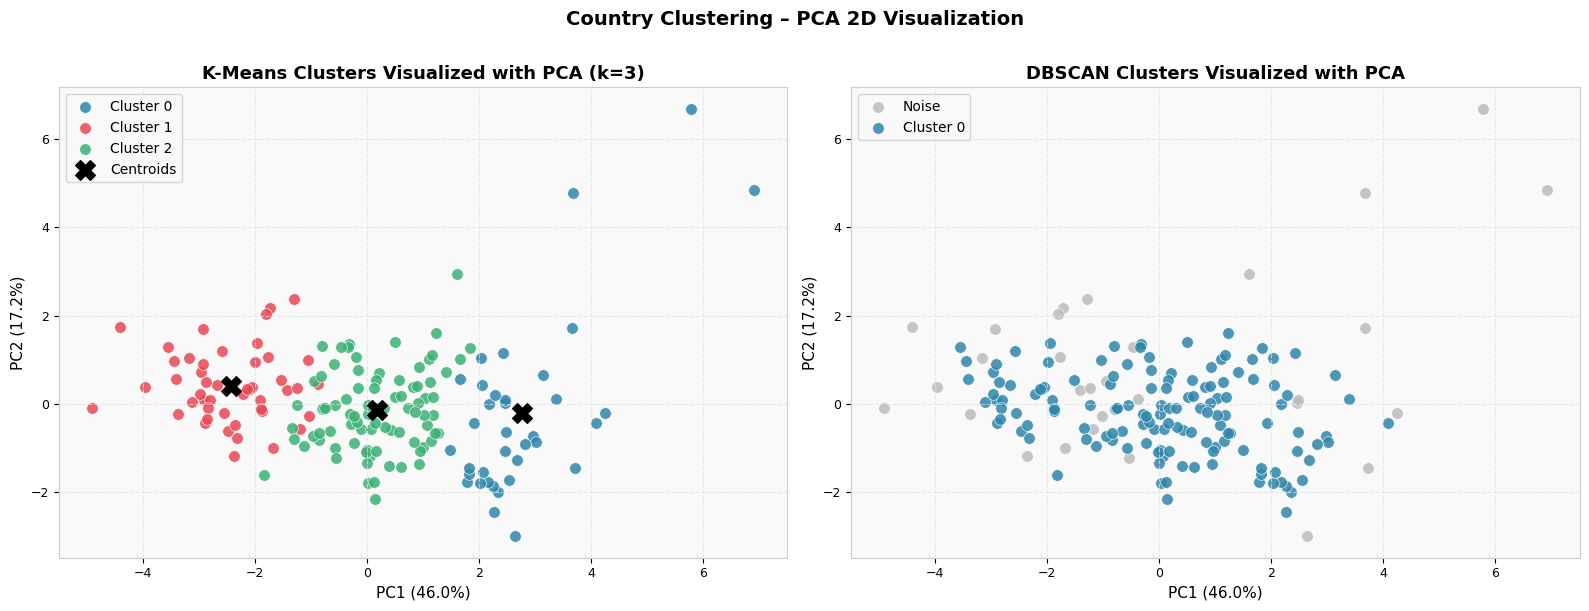

In [28]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var = pca.explained_variance_ratio_
print(f'PC1: {var[0]*100:.2f}%  |  PC2: {var[1]*100:.2f}%  |  Total: {sum(var)*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
for cid in range(best_k):
    mask = df['kmeans_cluster'] == cid
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=PALETTE[cid], label=f'Cluster {cid}',
                s=70, alpha=0.85, edgecolors='white', linewidths=0.5)

centroids_pca = pca.transform(kmeans.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')
ax1.set_title(f'K-Means Clusters Visualized with PCA (k={best_k})')
ax1.set_xlabel(f'PC1 ({var[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({var[1]*100:.1f}%)')
ax1.legend()

ax2 = axes[1]
unique_labels = np.unique(df['dbscan_cluster'])
ci = 0
for label in unique_labels:
    mask = df['dbscan_cluster'] == label
    color = '#bbbbbb' if label == -1 else PALETTE[ci % len(PALETTE)]
    name = 'Noise' if label == -1 else f'Cluster {label}'
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=name,
                s=70, alpha=0.85, edgecolors='white', linewidths=0.5)
    if label != -1:
        ci += 1
ax2.set_title('DBSCAN Clusters Visualized with PCA')
ax2.set_xlabel(f'PC1 ({var[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({var[1]*100:.1f}%)')
ax2.legend()

plt.suptitle('Country Clustering – PCA 2D Visualization', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 13) Cluster profiling

Average feature values per cluster:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


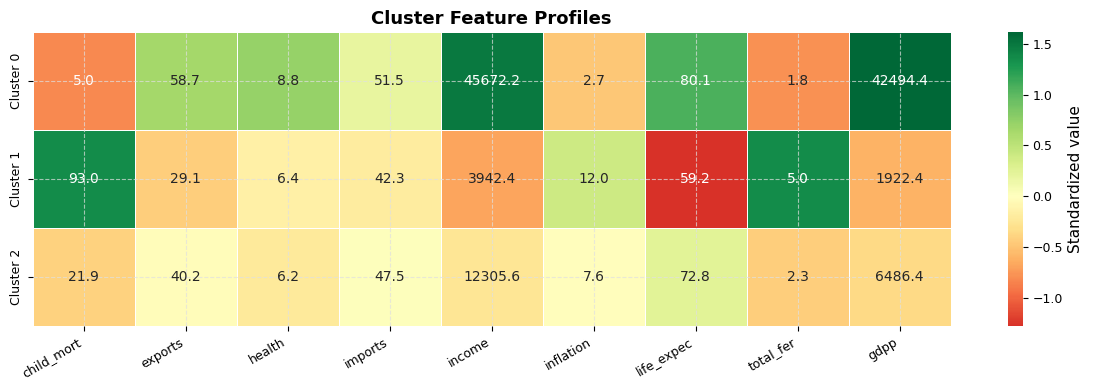

In [29]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
print('Average feature values per cluster:')
display(profile)

fig, ax = plt.subplots(figsize=(12, 4))
profile_scaled = pd.DataFrame(
    scaler.transform(profile),
    columns=numeric_cols,
    index=[f'Cluster {i}' for i in range(best_k)]
)
sns.heatmap(profile_scaled, annot=profile.values, fmt='.1f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label': 'Standardized value'}, ax=ax)
ax.set_title('Cluster Feature Profiles')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 14) Final insights

After looking at the cluster profiles and plots, here are my observations:

---

### Which cluster has high child mortality?
- Cluster 1 has the highest child mortality (93.0) with very low income (3942.4) and low life expectancy (59.2)
- These are the most underdeveloped countries and should be the top priority for aid

---

### Which cluster has high income and gdpp?
- Cluster 0 has the highest income (45672.2) and gdpp (42494.4)
- Child mortality is just 5.0 and life expectancy is 80.1 — clearly the developed nations

---

### Which cluster looks underdeveloped?
- Cluster 1 is the most underdeveloped
- Cluster 2 is the middle group — still developing but not as critical as Cluster 1

---

### Which countries should be prioritized for aid?
- Cluster 1 countries are the clear priority
- DBSCAN flagged many countries as noise/outliers — these may need individual attention
- K-Means gave more useful results than DBSCAN for this dataset

---

### Overall observations
- Elbow curve clearly bends at k=3 so that was the right choice
- PCA captures 63.2% variance (PC1=46%, PC2=17.2%) which is decent
- K-Means clusters are reasonably well separated in the PCA scatter plot